In [5]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time   # Переименование модуля time
import os

In [38]:

def process_audio_file(
    audio_file,
    game_duration=10.0,
    pitch_floor=100,
    pitch_ceiling=600,
    voicing_threshold=0.6,
    silence_threshold_db=45.0,
    blocks_to_silent=6,
    blocksize=1024,
    time_step=0.01,
    method="ac"
):
    """
    Анализ аудиофайла блоками (как реальное время), но без промежуточного графика.
    По окончании строит 3 сабплота:
      1. Интенсивность (дБ)
      2. Частота основного тона (Гц)
      3. Активность речи (0 - тишина, 1 - голос)
    Выводит только среднее время обработки блока.

    Параметры:
      - audio_file (str): путь к аудиофайлу
      - game_duration (float): максимальное время чтения (сек)
      - pitch_floor (float): нижняя граница основного тона
      - pitch_ceiling (float): верхняя граница основного тона
      - voicing_threshold (float): порог озвучивания (Parselmouth)
      - silence_threshold_db (float): порог громкости (дБ)
      - blocks_to_silent (int): через сколько блоков тишины обнулять голос
      - blocksize (int): размер блока (сэмплов)
      - time_step (float): шаг анализа частоты
      - method (str): 'ac' или 'cc' (Parselmouth)
    """

    # Массивы для итогового графика
    times = []
    intensities = []
    pitches = []
    voice_states = []

    block_times = []

    # Псевдо-RT логика
    silent_counter = 0
    last_valid_pitch = None
    voice_state = 0  # 0 - silence, 1 - voice

    start_time = time.time()

    print("Открываем аудиофайл...")
    with StreamFromFile(filename=audio_file, blocksize=blocksize) as sf:
        sf.set_methods(UnpackRawInFloat32())
        samplerate = sf.samplerate
        print(f"Частота дискретизации (из файла): {samplerate} Гц")

        current_time = 0.0

        while (time.time() - start_time) < game_duration:
            block_start = time.time()

            raw_data = sf.read(blocksize)
            if not raw_data:
                print("Файл прочитан полностью.")
                break

            signal = sf.chain_of_methods(raw_data)
            sound = parselmouth.Sound(values=signal, sampling_frequency=samplerate)

            # 1) Интенсивность
            intensity_obj = sound.to_intensity()
            intensity_vals = intensity_obj.values.T.flatten()
            avg_intensity = np.mean(intensity_vals) if len(intensity_vals) > 0 else -50

            # 2) Частота (pitch)
            if method == "ac":
                pitch_obj = sound.to_pitch_ac(
                    time_step=time_step,
                    pitch_floor=pitch_floor,
                    pitch_ceiling=pitch_ceiling,
                    voicing_threshold=voicing_threshold
                )
            else:
                pitch_obj = sound.to_pitch_cc(
                    time_step=time_step,
                    pitch_floor=pitch_floor,
                    pitch_ceiling=pitch_ceiling,
                    voicing_threshold=voicing_threshold
                )

            pitch_vals = pitch_obj.selected_array["frequency"]
            pitch_vals[(pitch_vals == 0) | (pitch_vals > pitch_ceiling)] = np.nan
            avg_pitch = np.nanmean(pitch_vals) if np.any(~np.isnan(pitch_vals)) else None

            # Проверка тишины
            if avg_intensity > silence_threshold_db:
                silent_counter = 0
                last_valid_pitch = avg_pitch
                voice_state = 1
            else:
                silent_counter += 1
                if silent_counter >= blocks_to_silent:
                    last_valid_pitch = None
                    voice_state = 0

            # Сохраняем данные
            times.append(current_time)
            intensities.append(avg_intensity)
            pitches.append(last_valid_pitch)
            voice_states.append(voice_state)

            # Засекаем время обработки блока
            block_end = time.time()
            block_times.append(block_end - block_start)

            # Увеличиваем время
            current_time += blocksize / samplerate

    # Вывод среднего времени обработки блока
    if block_times:
        avg_block_time = np.mean(block_times)
        print(f"Среднее время обработки блока: {avg_block_time:.6f} секунд")
    else:
        print("Нет данных о времени обработки.")

    # Построение 3-х сабплотов
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True)

    # 1) Интенсивность
    axes[0].plot(times, intensities, color="blue")
    axes[0].set_ylabel("Интенсивность (дБ)")
    axes[0].set_title("Интенсивность звука")
    axes[0].grid()

   # 2) Частота
    pitches_array = np.array([np.nan if p is None else p for p in pitches])  # Преобразуем в массив
    axes[1].plot(times, pitches_array, color="red", marker="o", linestyle="")
    axes[1].set_ylabel("Частота (Гц)")
    axes[1].set_title("Частота основного тона")
    axes[1].set_ylim(0, pitch_ceiling + 50)  # Небольшой запас
    axes[1].grid()

    # 3) Активность речи
    axes[2].step(times, voice_states, color="green", where="post")
    axes[2].set_ylabel("Активность речи\n(0 - silent, 1 - voiced)")
    axes[2].set_xlabel("Время (с)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].grid()

    plt.tight_layout()
    plt.show()

    print("Анализ завершён.")  # Конец


Открываем аудиофайл...
Частота дискретизации (из файла): 16000 Гц
Среднее время обработки блока: 0.000272 секунд


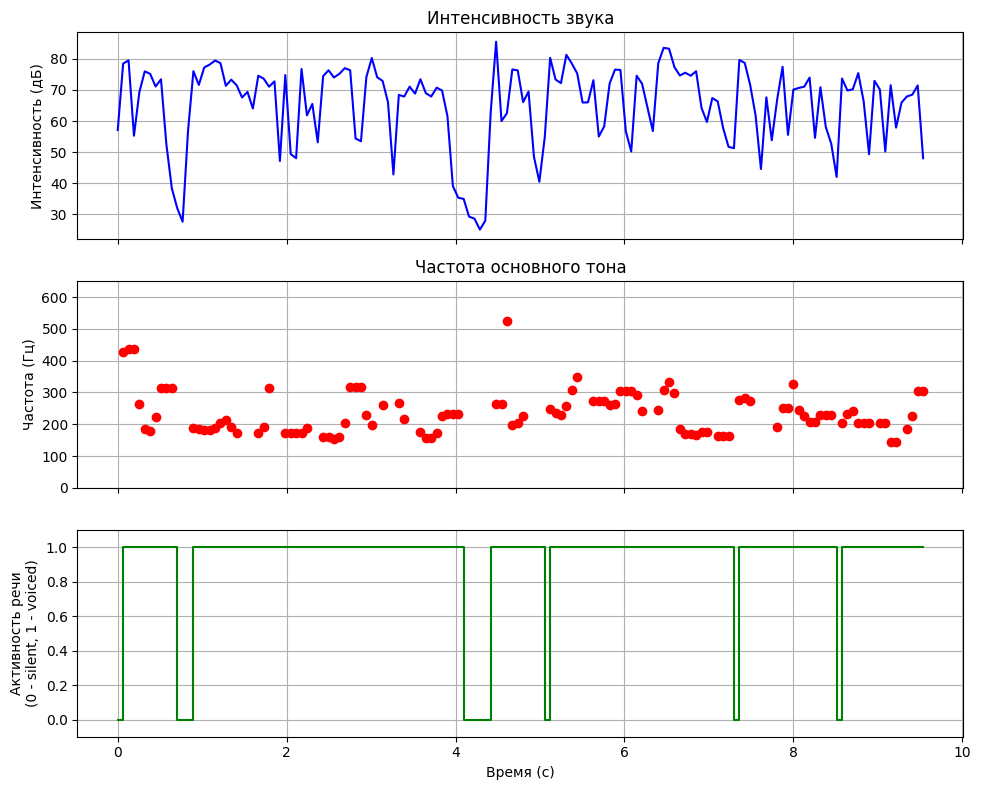

Анализ завершён.


In [39]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Перемещаемся на уровень вверх
audio1 = os.path.join(BASE_DIR, 'silero_vad/files/femalechist2.wav')
process_audio_file(
    audio_file=audio1,
    game_duration=8.0,           # Сколько максимум времени «симулировать»
    pitch_floor=100,
    pitch_ceiling=600,
    voicing_threshold=0.6,
    silence_threshold_db=60.0,
    blocks_to_silent=3,
    blocksize=1024,
    time_step=0.01,
    method="ac"
)